# 📊 Campaign Intelligence RAG — Self-Query + Parent-Child Fusion, with Agentic Routing

## Project Overview

This notebook builds a **hybrid retrieval-augmented generation (RAG) system** over a marketing "campaign intelligence" dataset (`campaign_intelligence_sample.csv`), and wraps it in a **LangGraph agentic pipeline** that can decide, per query, whether to answer using:

1. **Vector retrieval** (qualitative/descriptive questions about campaigns), or
2. **A pandas DataFrame agent** (quantitative/aggregation questions like "highest revenue", "compare territories"), or
3. **Both**, when a question mixes the two.

### Key building blocks

| Component | Purpose |
|---|---|
| **Self-Query Retriever** | Uses an LLM to turn a natural-language question into a semantic search + structured metadata filter (e.g., `territory = 'North'`, `revenue > 500000`) against Chroma. |
| **Parent-Document Retriever** | Splits documents into small *child* chunks for embedding/matching, but keeps the full *parent* document in a separate store — so search precision comes from small chunks while the LLM still gets full context. |
| **Custom Fusion Retriever** (`SelfQueryParentChildRetriver`) | Combines the two above: it runs the Self-Query retriever to find matching *child* chunks (with metadata filtering + semantic relevance), then resolves each hit back to its full **parent** document before returning it. |
| **Contextual Compression** | Further trims retrieved parent documents down to only the relevant sentences (embedding similarity filter + LLM extraction) before they reach the generator. |
| **Pandas DataFrame Agent** | A separate LLM-driven agent that writes and executes pandas code directly against the source DataFrame for aggregation/comparison questions the retriever can't answer. |
| **LangGraph pipeline** | Orchestrates: query classification → retrieval and/or pandas execution → answer generation → LLM-as-judge grading → optional regeneration loop (up to a max retry count). |

### Flow at a glance

```
START → DecionNode (classify: Agent / Regular / Both)
      → retriver_node (vector RAG)  and/or  Agent_Execution (pandas agent)
      → Regular_Augmentation / Agent_Augmentation / combine_node (build prompt)
      → Generation (LLM answer)
      → LLm_AS_judge (grounded? Good/Rework)
      → END  or  loop back to Generation with judge feedback
```

The cells below are commented in order, from data loading and retriever construction, through the LangGraph pipeline definition, to the end-to-end test queries.

## 🧩 Imports & LLM Initialization

**What this cell does:**
- Loads all the libraries used across the notebook:
  - `ChatOpenAI` — the chat LLM wrapper used both as the "brain" of the pipeline and inside the retrievers.
  - `ParentDocumentRetriever`, `SelfQueryRetriever`, `MultiQueryRetriever` — the three LangChain retriever strategies that get fused together later in this notebook.
  - `AttributeInfo` — schema class used to describe filterable metadata fields to the Self-Query retriever.
  - `ChromaTranslator` — converts a Self-Query retriever's structured filter into a Chroma-compatible `where` clause.
  - `BaseRetriever` — base class used later to build the **custom fusion retriever** (`SelfQueryParentChildRetriver`).
  - `StateGraph, START, END` (LangGraph) — used to build the agentic RAG graph/pipeline at the bottom of the notebook.
  - `ContextualCompressionRetriever` + `LLMChainExtractor` / `DocumentCompressorPipeline` / `EmbeddingsFilter` — used to compress/filter retrieved context before it's sent to the generator LLM.
  - `create_pandas_dataframe_agent` — a LangChain agent that can write & execute pandas code against the campaign dataframe, used for aggregation-type questions the vector retriever can't answer.
- Loads environment variables (`.env`) via `dotenv` (expected to contain `OPENAI_API_KEY`, etc.).
- Instantiates two chat models:
  - `model` — the primary/orchestrator LLM used for generation, judging, and the self-query retriever's query construction.
  - `data_agent` — a separate `gpt-4.1-mini` model dedicated to the pandas dataframe agent (kept small/cheap since it's just doing code generation over structured data).

In [38]:
from langchain_openai import ChatOpenAI
from langchain_classic.retrievers import ParentDocumentRetriever, SelfQueryRetriever, MultiQueryRetriever
from langchain_classic.chains.query_constructor.schema import AttributeInfo
from langchain_community.query_constructors.chroma import ChromaTranslator
from langchain_core.retrievers import BaseRetriever
from typing import Type, List
import os
from langchain_core.documents import Document
from langgraph.graph import StateGraph, START, END

from langchain_classic.retrievers import ContextualCompressionRetriever
from langchain_classic.retrievers.document_compressors import (LLMChainExtractor, DocumentCompressorPipeline, EmbeddingsFilter)

from dotenv import load_dotenv
load_dotenv()

from langchain_experimental.agents import create_pandas_dataframe_agent

model = ChatOpenAI(model = 'gpt-5.6-luna')
data_agent=ChatOpenAI(model='gpt-4.1-mini')



## 📥 Load CSV → Build LangChain `Document`s + Self-Query Metadata Schema

**What this cell does:**

1. **Loads the source CSV** (`campaign_intelligence_sample.csv`) into a pandas DataFrame `df`. Each row is one marketing campaign with descriptive text fields (`event_description`, `cross_group_description`, `reactivation_description`, `final_insight`, `combined_description`) and numeric/categorical metrics (`revenue`, `tg_count`, `cg_count`, `lift_percent`, `response_rate_percent`, `atbms`).

2. **Builds one `Document` per row**, using `combined_description` (a pre-merged narrative of the campaign) as the embeddable `page_content`, and attaches all the structured fields as `metadata` — explicitly casting numeric columns to native Python `float`/`int` (important: Chroma's filter engine chokes on numpy scalar types like `numpy.int64`).

3. **Defines `SafeChromaTranslator`**, a subclass of `ChromaTranslator` that intercepts every filter comparison built by the Self-Query retriever and coerces the comparison value to a native Python `int`/`float` before Chroma sees it. This is a defensive fix for the same numpy-type issue — LLM-constructed filters or pandas-derived values can otherwise leak numpy types into the `where` clause and break Chroma's query validation.

4. **Defines `meta_data_field`** — a list of `AttributeInfo` objects describing each metadata field (name, natural-language description, type) to the Self-Query retriever's LLM, so it knows which fields exist and what values/ranges to expect when translating a question into a structured filter (e.g., "campaigns in North with lift > 10%" → `territory == 'North' AND lift_percent > 10`).

5. **Defines `document_content_description`** — a short description of what the embedded text actually represents, which the Self-Query retriever's LLM uses to decide what belongs in the semantic-search part of a query versus the metadata-filter part.

In [2]:
import pandas as pd
from langchain_core.documents import Document
from langchain_classic.chains.query_constructor.schema import AttributeInfo

# ---------- STEP 1: CSV Load karo ----------
CSV_PATH = r"C:\Users\kuntal.chakraborty\Downloads\campaign_intelligence_sample.csv"
df = pd.read_csv(CSV_PATH)

# ---------- STEP 2: Documents banao (metadata LLM ke bina, direct mapping) ----------
docs = []
for _, row in df.iterrows():
    doc = Document(
        page_content=row["combined_description"],   # ye text embed hoga
        metadata={
            "campaign_id": row["campaign_id"],
            "territory": row["territory"],
            "quarter": row["quarter"],
            "cohort": row["cohort"],
            "revenue": float(row["revenue"]),
            "tg_count": int(row["tg_count"]),
            "cg_count": int(row["cg_count"]),
            "lift_percent": float(row["lift_percent"]),
            "response_rate_percent": float(row["response_rate_percent"]),
            "atbms": float(row["atbms"]),
        }
    )
    docs.append(doc)

print(f"Total documents created: {len(docs)}")
print(docs[0])


from langchain_community.query_constructors.chroma import ChromaTranslator
from langchain_classic.chains.query_constructor.ir import Comparison

class SafeChromaTranslator(ChromaTranslator):
    def visit_comparison(self, comparison: Comparison) -> dict:
        # Force any numeric-looking value to a native Python int/float
        value = comparison.value
        if isinstance(value, (int, float)) or hasattr(value, "item"):
            try:
                value = float(value) if isinstance(value, float) or hasattr(value, "item") else int(value)
            except (TypeError, ValueError):
                pass
            # Rebuild comparison with the coerced native value
            comparison = Comparison(
                comparator=comparison.comparator,
                attribute=comparison.attribute,
                value=value
            )
        return super().visit_comparison(comparison)

# ---------- STEP 3: metadata_field_info (Self-Query Retriever ke liye) ----------
meta_data_field = [
    AttributeInfo(
        name="campaign_id",
        description="Unique campaign identifier, e.g. 'CMP1001', 'CMP1002'",
        type="string"
    ),
    AttributeInfo(
        name="territory",
        description="Geographic territory of the campaign. One of: 'North', 'South', 'East', 'West', 'Central'",
        type="string"
    ),
    AttributeInfo(
        name="quarter",
        description="Fiscal quarter in which the campaign ran. One of: 'Q1', 'Q2', 'Q3', 'Q4'",
        type="string"
    ),
    AttributeInfo(
        name="cohort",
        description="Customer cohort/segment targeted by the campaign. One of: 'New User', 'Price Sensitive', 'Dormant', 'High Value', 'Frequent Buyer'",
        type="string"
    ),
    AttributeInfo(
        name="revenue",
        description="Total revenue generated by the campaign (in currency units), ranges roughly 50000 to 900000",
        type="float"
    ),
    AttributeInfo(
        name="tg_count",
        description="Target group customer count for the campaign, ranges roughly 5000 to 50000",
        type="integer"
    ),
    AttributeInfo(
        name="cg_count",
        description="Control group customer count for the campaign, ranges roughly 2000 to 20000",
        type="integer"
    ),
    AttributeInfo(
        name="lift_percent",
        description="Incremental lift percentage of target group vs control group, ranges roughly -5 to 35",
        type="float"
    ),
    AttributeInfo(
        name="response_rate_percent",
        description="Campaign response rate percentage, ranges roughly 1.5 to 22",
        type="float"
    ),
    AttributeInfo(
        name="atbms",
        description="Average transaction basket / metric score for the campaign, ranges roughly 300 to 2500",
        type="float"
    ),
]

document_content_description = (
    "Campaign intelligence summaries combining event description, cross-group analysis, "
    "reactivation insights, and final recommendation for marketing campaigns across territories."
)

Total documents created: 40
page_content='Campaign CMP1001 (Q1, North): New product launch campaign aimed at New User customers in North region. Cross-group analysis shows New User customers responded 15% better than control group in North. Reactivation efforts for dormant New User customers in North led to 8% win-back rate. Overall, the campaign drove strong revenue lift in North with New User segment showing the best response. Recommend scaling this cohort in upcoming quarters.' metadata={'campaign_id': 'CMP1001', 'territory': 'North', 'quarter': 'Q1', 'cohort': 'New User', 'revenue': 168607.24, 'tg_count': 21049, 'cg_count': 9314, 'lift_percent': -0.9, 'response_rate_percent': 16.68, 'atbms': 1499.81}


## 🐼 Pandas DataFrame Agent (Aggregation Path)

Creates `data_agent` — a LangChain **pandas dataframe agent** wrapping the `df` loaded above, powered by the `gpt-4.1-mini` model instantiated earlier.

- `allow_dangerous_code=True` permits the agent to actually execute the Python/pandas code it generates (required for it to compute real aggregations like sums, means, sorts, top-N, etc.).
- `verbose=True` prints the agent's intermediate reasoning/tool calls, useful for debugging.

This agent is the system's answer to questions the vector retriever structurally cannot handle — e.g. "which campaign has the highest revenue" or "compare average revenue between territories" — since those require computing over the *entire* dataset rather than semantically matching a few documents. It's invoked later inside `Agent_Execution` / `combine_node` in the LangGraph pipeline.

In [3]:
data_agent=create_pandas_dataframe_agent(
    llm=data_agent,
    df=df ,
    allow_dangerous_code=True,
    verbose=True

)

## 🗄️ Chroma Vector Store Initialization

Creates `chrma_db`, an (initially empty) **Chroma** vector store using `OpenAIEmbeddings` as the embedding function. No `persist_directory` is passed, so this is an **in-memory, non-persistent** collection — it will be populated later by `ParentDocumentRetriever.add_documents(...)`.

This single vector store is shared by both the Self-Query retriever and the Parent-Document retriever — it only ever stores the small **child** chunks; the corresponding full **parent** documents live separately in `parent_docstore` (an `InMemoryStore`), linked via a `doc_id` in each child chunk's metadata.

In [4]:
from langchain_chroma import Chroma
from langchain_openai import OpenAIEmbeddings
chrma_db = Chroma(embedding_function=OpenAIEmbeddings(),
)

## 🔎 Self-Query Retriever + Multi-Query Retriever

- **`self_query_retriever`**: built via `SelfQueryRetriever.from_llm(...)`, wiring together:
  - `model` — the LLM that translates a natural-language query into a structured `(semantic query, metadata filter)` pair.
  - `chrma_db` — the vector store to search.
  - `meta_data_field` — the metadata schema defined earlier, so the LLM knows which fields it can filter on.
  - `SafeChromaTranslator()` — converts the structured filter into a Chroma-safe `where` clause (native Python types only).
  - `document_contents` — description of what's embedded, to help the LLM separate "what to filter on" from "what to search semantically."
  - `search_type="mmr"` with `search_kwargs` — uses **Maximal Marginal Relevance** search (`k=10` results, `fetch_k=30` candidates, `lambda_mult=0.5` balancing relevance vs. diversity) instead of plain top-k similarity, to reduce redundant/near-duplicate chunk retrieval.

- **`multi_query_retriver`**: wraps `self_query_retriever` in a `MultiQueryRetriever`, which asks the LLM to generate several rephrasings of the input question, runs each through the base retriever, and unions/deduplicates the results — intended to improve recall for queries that are phrased ambiguously or narrowly.

  > ℹ️ Note: `multi_query_retriver` is constructed here but is **not** currently wired into `custom_retriver` or the LangGraph pipeline below — the pipeline uses `self_query_retriever` directly (via the custom fusion retriever). It's available if you want to swap it in for extra recall.

In [5]:
self_query_retriever = SelfQueryRetriever.from_llm(
    llm = model,
    vectorstore=chrma_db,
    metadata_field_info=meta_data_field,
    structured_query_translator=SafeChromaTranslator(),
    document_contents=document_content_description,
    search_type="mmr",
    search_kwargs={'k':10, 'lambda_mult':0.5, 'fetch_k':30}
    
)



multi_query_retriver=MultiQueryRetriever.from_llm(
    retriever=self_query_retriever, 
    llm=model,
)

## 👨‍👩‍👧 Parent-Document Retriever Setup

Configures the **Parent-Child** half of the fusion strategy:

- `p_spliter` — `RecursiveCharacterTextSplitter` producing large **parent** chunks (`chunk_size=1000`, `chunk_overlap=100`) — these preserve broad context.
- `c_spliter` — a second splitter producing small **child** chunks (`chunk_size=300`, `chunk_overlap=50`) from each parent — small chunks embed more precisely and match narrower queries better.
- `parent_docstore` — an `InMemoryStore` that will hold the full parent documents, keyed by an auto-generated `doc_id`.
- `parent_child_retriver` — a `ParentDocumentRetriever` tying it all together: it splits each source `Document` into parents, splits each parent into children, embeds only the **children** into `chrma_db` (each child's metadata gets a `doc_id` pointing back to its parent), and stores the **parents** in `parent_docstore`.
- `parent_child_retriver.add_documents(docs)` — runs this whole split → embed → store pipeline over all 40 campaign documents built earlier. After this call, `chrma_db` contains the child-chunk vectors that the Self-Query retriever searches over, and `parent_docstore` contains the full parent text that gets returned to the user.

In [6]:
from langchain_classic.storage import (InMemoryStore, LocalFileStore, create_kv_docstore)

from langchain_text_splitters import RecursiveCharacterTextSplitter


p_spliter=RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=100)
c_spliter=RecursiveCharacterTextSplitter(chunk_size=300, chunk_overlap=50)
parent_docstore=InMemoryStore()

parent_child_retriver=ParentDocumentRetriever(
    parent_splitter=p_spliter,
    child_splitter=c_spliter,
    docstore=parent_docstore,
    vectorstore=chrma_db,

)

parent_child_retriver.add_documents(docs)




## 🔀 Custom Fusion Retriever: `SelfQueryParentChildRetriver`

This is the **core custom class that fuses Self-Query retrieval with Parent-Child retrieval** — the main idea of the notebook.

- Extends `BaseRetriever` (so it's a drop-in LangChain retriever usable anywhere one is expected, e.g. inside `ContextualCompressionRetriever` or a chain).
- Holds two references: `SelfQueryRetriever` (the self-query retriever built earlier) and `parent_docstore` (the parent document store from the Parent-Document retriever).
- **`_get_relevant_documents(query)`** — the retrieval logic:
  1. Calls `self.SelfQueryRetriever.invoke(query)` — this both (a) extracts a metadata filter + semantic query from the natural-language `query`, and (b) does MMR similarity search over the **child chunks** in Chroma, applying that filter.
  2. Reads the `doc_id` metadata off each returned child chunk and collects the **unique set of parent IDs** referenced.
  3. Looks up each parent ID in `parent_docstore` (`mget`) to fetch the **full parent `Document`**, filtering out any `None` misses.
  4. Returns the list of full parent documents (not the small child chunks) — so the caller gets precise, filtered matches *with full surrounding context*, rather than fragmented 300-character snippets.

This is the key benefit of the fusion: Self-Query gives precise metadata + semantic filtering at the (small, embedding-friendly) child-chunk level, while the parent-child mechanism ensures the LLM ultimately sees full, coherent campaign narratives rather than disconnected fragments.

In [7]:
import warnings 
warnings.filterwarnings('ignore')
class SelfQueryParentChildRetriver(BaseRetriever):
    SelfQueryRetriever : BaseRetriever   
    
    parent_docstore : object

    def _get_relevant_documents(self, query: str) ->List[Document] :
        child_doc=self.SelfQueryRetriever.invoke(query)
        parent_ids = set(doc.metadata['doc_id'] for doc in child_doc)
        parent_doc = [self.parent_docstore.mget([pid])[0] for pid in parent_ids]
        parent_doc = [doc for doc in parent_doc if doc is not None]
        return parent_doc

## ⚙️ Instantiate the Fused Retriever

Creates `custom_retriver`, the actual working instance of `SelfQueryParentChildRetriver`, wiring together:
- `self_query_retriever` — for metadata-filtered + semantic child-chunk search.
- `parent_docstore` — for resolving hits back to full parent documents.

**This is the single retriever object used everywhere downstream** (manual tests, the compression pipeline, and the LangGraph `retriver_node`), representing the complete Self-Query + Parent-Child fusion.

In [8]:
custom_retriver = SelfQueryParentChildRetriver(SelfQueryRetriever=self_query_retriever, 
                                               parent_docstore=parent_docstore)



## 👀 Data Sanity Check

Quick `df.head(2)` preview to confirm the CSV loaded correctly and to visually cross-reference the raw columns (`event_description`, `cross_group_description`, etc.) against the `combined_description` and metadata used to build the `Document`s above.

In [9]:
df.head(2)

,campaign_id,territory,quarter,cohort,event_description,cross_group_description,reactivation_description,final_insight,combined_description,revenue,tg_count,cg_count,lift_percent,response_rate_percent,atbms
0,CMP1001,North,Q1,New User,New product launch campaign aimed at New User ...,Cross-group analysis shows New User customers ...,Reactivation efforts for dormant New User cust...,"Overall, the campaign drove strong revenue lif...","Campaign CMP1001 (Q1, North): New product laun...",168607.24,21049,9314,-0.90,16.68,1499.81
1,CMP1002,South,Q2,Price Sensitive,New product launch campaign aimed at Price Sen...,Cross-group results reveal strong incremental ...,Reactivation campaign show low engagement amon...,"Overall, the campaign drove strong revenue lif...","Campaign CMP1002 (Q2, South): New product laun...",527058.30,44453,2869,23.64,15.88,1222.94


## 🧪 Manual Test: Fused Retriever on a Multi-Campaign Query

Runs `custom_retriver.invoke(...)` directly (outside the LangGraph pipeline) with a query mentioning two specific campaign IDs (`CMP1004`, `CMP1002`), and prints each returned document's full text.

Purpose: a quick eyeball check that the Self-Query → Parent-Child fusion correctly narrows to the right campaigns *and* returns their **full parent narrative** (not truncated child chunks) before wiring this retriever into the larger graph.

In [10]:
res=custom_retriver.invoke("Tell me about the campaign CMP1004 and CMP1002 ?")
for i, d in enumerate(res):
    print(f"{[i+1]}:::: {d.page_content}")
    print()
    print("*"*100)

[1]:::: Campaign CMP1002 (Q2, South): New product launch campaign aimed at Price Sensitive customers in South region. Cross-group results reveal strong incremental revenue for Price Sensitive customers vs holdout group. Reactivation campaign show low engagement among Price Sensitive customers, suggests channel mismatch. Overall, the campaign drove strong revenue lift in South with Price Sensitive segment showing the best response. Recommend scaling this cohort in upcoming quarters.

****************************************************************************************************
[2]:::: Campaign CMP1004 (Q4, North): Loyalty reward push for Price Sensitive customers, offering bonus points on repeat purchase. Cross-group results reveal strong incremental revenue for Price Sensitive customers vs holdout group. Reactivation efforts for dormant Price Sensitive customers in North led to 8% win-back rate. Strong performance across North for Price Sensitive cohort, with top-3 insights being

## 🔬 Inspect Raw Chroma Metadata (Type Verification)

Pulls one raw record directly from the underlying Chroma collection (`chrma_db._collection.get(...)`) and prints its metadata dict plus the Python `type()` of the `revenue` field.

Purpose: confirms that the earlier defensive type-casting (native `float`/`int` conversion in the `Document` metadata, plus `SafeChromaTranslator`) actually worked — i.e., numeric metadata is stored as plain Python `float`, not a numpy scalar that could later break filter comparisons.

In [11]:
result = chrma_db._collection.get(limit=1, include=['metadatas'])
print(result['metadatas'][0])
print(type(result['metadatas'][0]['revenue']))

{'tg_count': 21049, 'doc_id': 'f353e39e-a132-47d0-8754-402a8d143235', 'cohort': 'New User', 'campaign_id': 'CMP1001', 'quarter': 'Q1', 'cg_count': 9314, 'territory': 'North', 'atbms': 1499.81, 'lift_percent': -0.9, 'response_rate_percent': 16.68, 'revenue': 168607.24}
<class 'float'>


## 🔁 (Redundant) LangGraph Import

Re-imports `StateGraph, START, END` — already imported in the very first setup cell. Harmless duplicate, kept here as a lead-in to the LangGraph pipeline section that follows.

In [12]:
from langgraph.graph import StateGraph, START, END

## 🗺️ Graph State Schema + Query-Routing Decision Node

This cell defines the **shared state** and the **first routing step** of the LangGraph pipeline.

- **`RagSchema` (TypedDict)** — the state object threaded through every node of the graph. Key fields:
  - `query` — the raw user question.
  - `context` — text retrieved by the vector retriever.
  - `decison` / `verdict` — routing decision (`Agent` / `Regular` / `Both`) and the LLM's justification.
  - `pandas_query` / `regular_query` — the sub-question(s) drafted for each path.
  - `agent_ans` — the pandas agent's raw output.
  - `augmented_question` — the fully-built prompt handed to the generator.
  - `final_ans` — the generator's answer.
  - `judge_decison` / `judge_feedback` (accumulated via `Annotated[..., add]`, so feedback from every judging round is appended, not overwritten) / `max_try` — the self-correction loop's state.

- **`JudgeSchema` (Pydantic)** — structured output contract for the LLM-as-judge node: `judge_decison` (`Rework` or `Good`) plus `judge_feedback` explaining why.

- **`Deciosn` (Pydantic)** — structured output contract for the routing LLM: which path(s) to take (`Agent` / `Regular` / `Both`), a `verdict` explaining the choice, and a drafted `pandas_query` / `regular_query` for each relevant path.

- **`DecionNode(state)`** — the first real node in the graph. Calls `gpt-4.1-mini` with structured output (`Deciosn`) and a system prompt instructing it to:
  - Detect aggregation/comparison intent (e.g. "best", "compare", "greater than") → route to the pandas **Agent** path.
  - Otherwise → route to the **Regular** RAG path.
  - If a question has both a computed part and a descriptive part → route to **Both**, drafting a separate sub-query for each.
  - It's given the dataframe's column list so it can write a sensible `pandas_query` description.

- **`Deciosn_Router_final(state)`** — the LangGraph **conditional edge function** consuming `state['decison']`: routes to `"Agent_Execution"` if `Agent`, otherwise to `"retriver_node"` (covers both `Regular` and `Both`, since the vector retrieval step still runs for `Both` before splitting off into `combine_node`).

In [40]:
from pydantic import BaseModel, Field
from typing import TypedDict, Literal, Annotated
from langchain_core.prompts import *
from operator import add


class RagSchema(TypedDict):
    query: str 
    context: str
    augmented_question: str
    decison : str
    agent_ans: str 
    regular_ans : str 
    final_ans: str
    pandas_query: str 
    regular_query: str
    verdict : str 
    judge_decison: str 
    judge_feedback: Annotated[List[str] , add]
    max_try : int = 0 

class JudgeSchema(BaseModel):
    judge_decison: Literal['Rework', "Good"] = Field(description="If the answer is grounded then good else rework")
    judge_feedback: str = Field(description="Why the decison was taken and what imporvement need to be done")
    
     

class Deciosn(BaseModel):
    decison : Literal["Agent", "Regular", "Both"] = Field(description="Decison wheather the query should go the Agent (pandas agent) or Regular rag path: Agent doest the aggregation, Regular path does't have aggreagtion capability")
    verdict : str = Field(description="Why this decion is taken ")
    pandas_query : str
    regular_query: str 



def DecionNode(state: RagSchema):
    struct_llm=ChatOpenAI(model='gpt-4.1-mini').with_structured_output(Deciosn)

    system_prompt="""You are a query analyizer to take decision wheather the query should first go to the query or to the regular rag path the question is given by the user. 
    - You need to see the query and break it down to a pandas query for those queries which you see it has 'compaire, greater than or which is the best'  and those type of query which need a aggreagtion help 
    - Remeber the Rag system can't answer the aggreation type query if you see any aggregation return Agent path strictly
    - for the col list see the list here Column list :
            ['campaign_id',
            'territory',
            'quarter',
            'cohort',
            'event_description',
            'cross_group_description',
            'reactivation_description',
            'final_insight',
            'combined_description',
            'revenue',
            'tg_count',
            'cg_count',
            'lift_percent',
            'response_rate_percent',
            'atbms']
    - If the query has both type of the query mix then retun Both 
    for this kind of question given below 
        [tell me what is the best campaign by territoy, tell me a brief description about the campign C123]
        - For this kind of query you need to make pandas_query and regular_query both
    """

    prompt=ChatPromptTemplate.from_messages([
        ('system', system_prompt),
        ('human', """Question : \n {question}""")
    ])

    r = struct_llm.invoke(prompt.invoke({"question": state['query']}))   

    return {
        "decison": r.decison ,
        "verdict": r.verdict,
        "pandas_query": r.pandas_query ,
        "regular_query": r.regular_query
    }


def Deciosn_Router_final(state: RagSchema):
    if state['decison']=="Agent":
        return "Agent_Execution"
    if state['decison']=="Regular":
        return "retriver_node"
    else: 
        return "retriver_node"
        

## 📚 Retrieval Nodes (Plain vs. Compressed)

Defines two alternative retrieval node implementations for the graph:

- **`retriver_node_normal(state)`** — the simple version: calls `custom_retriver.invoke(state['query'])` directly and joins the returned parent documents' `page_content` into one context string. Kept as a lighter-weight reference implementation (not wired into the compiled graph below).

- **`retriver_node(state)`** — the version actually used in the graph. Wraps `custom_retriver` in a **`ContextualCompressionRetriever`** pipeline with two stages, applied in order:
  1. **`EmbeddingsFilter`** (`similarity_threshold=0.65`) — drops any retrieved parent document whose embedding similarity to the query falls below the threshold, cutting obviously irrelevant results.
  2. **`LLMChainExtractor`** (using `model`) — for each surviving document, asks the LLM to extract *only* the sentences/spans relevant to the query, discarding the rest.

  The compressed, filtered documents are then joined into the final `context` string. This keeps the prompt sent to the generator smaller and more focused than passing full parent documents verbatim.

In [41]:
def retriver_node_normal(state: RagSchema):
    
    context="\n\n...\n".join([i.page_content for i in custom_retriver.invoke(state['query']) if i.page_content is not None ])
    


    return {"context": context}





def retriver_node(state: RagSchema):
    llm_extract_compressor=LLMChainExtractor.from_llm(
        llm=model
    )

    filter_compressor=EmbeddingsFilter(
        embeddings=OpenAIEmbeddings(),
        similarity_threshold=0.65
    )

    compresor_pipeline=DocumentCompressorPipeline(transformers=[filter_compressor, llm_extract_compressor])

    compresor_retriver=ContextualCompressionRetriever(
        base_compressor=compresor_pipeline, 
        base_retriever= custom_retriver
    )

    context="\n\n...\n".join([i.page_content for i in compresor_retriver.invoke(state['query']) if i.page_content is not None ])
        
    
    
    return {"context": context}
    
    


## 📋 Column Reference

`df.columns` — a quick check of the DataFrame's column names. These same names are hard-coded into several prompts later (`DecionNode`'s system prompt, the pandas agent's `prefix` in `Agent_Execution`/`combine_node`), so this cell doubles as a reference for keeping those prompts in sync with the actual data schema.

In [42]:
df.columns

Index(['campaign_id', 'territory', 'quarter', 'cohort', 'event_description',
       'cross_group_description', 'reactivation_description', 'final_insight',
       'combined_description', 'revenue', 'tg_count', 'cg_count',
       'lift_percent', 'response_rate_percent', 'atbms'],
      dtype='object')

## 🔧 Runnables Import

Imports `langchain_core.runnables` (wildcard) — brings `RunnableLambda`, `RunnablePassthrough`, etc. into scope for use by the prompt/chain-building code in the next cell.

In [43]:
from langchain_core.runnables import *

## 🧠 Prompt Building, Pandas Execution, Combination & Self-Correction Loop

This is the largest cell in the notebook — it defines every remaining node in the graph. Read top to bottom:

- **`system_prompt`** — instructions for the *pure-retrieval* generator: answer strictly from the given context, and explicitly refuse ("I don't know") if the context doesn't support an answer. Enforces groundedness for the RAG-only path.

- **`system_prompt_agent`** — instructions for the *pure-aggregation* generator: treat the pandas agent's computed answer as ground truth (no second-guessing), phrase numbers naturally, and stick strictly to the computed, data-driven result.

- **`Regular_Augmentation(state)`** — builds the final prompt for the **Regular** path: `system_prompt` + a human message containing the retrieved `context` and the original `query`.

- **`Agent_Execution(state)`** — the **Agent** path's execution node. Spins up a *fresh* `create_pandas_dataframe_agent` (gpt-4.1-mini) each call, with a `prefix` reminding it of the dataframe's columns, and runs the user's `query` against it. Stores the agent's textual output in `agent_ans`.

- **`combine_node(state)`** — handles the **Both** path. Runs another pandas agent invocation, but this time passing *both* the original query and the drafted `pandas_query` sub-question so the agent knows which part to compute. Appends the pandas result to the already-retrieved vector `context` under a clear "**Aggregated part of the query answer is given below**" heading, then builds a combined prompt instructing the LLM to answer *every part* of the original question — numeric claims from the computed answer, descriptive claims from the retrieved context.

- **`Agent_Augmentation(state)`** — builds the final prompt for the **Agent**-only path: `system_prompt_agent` + the agent's answer, the query, and the pandas query used (for transparency/traceability).

- **`Retrive_router(state)`** — conditional edge after `retriver_node`: if the routing decision was `Both`, go to `combine_node` (which itself also invokes the pandas agent); otherwise go straight to `Regular_Augmentation`.

- **`LLm_AS_judge(state)`** — the **LLM-as-judge / self-correction** node (structured output via `JudgeSchema`, model `gpt-4.1-mini`). Given the query, retrieved context, agent answer, and the sub-queries, it grades whether the just-generated answer is properly grounded:
  - Returns `judge_decison = "Good"` or `"Rework"` plus bullet-point `judge_feedback` explaining the verdict.
  - Handles edge cases explicitly in its own system prompt (context blank → treat agent answer as the context; both blank → say "don't know").
  - Capped at **3 attempts** (`max_try`) — beyond that it force-passes with `"Good"` to guarantee the graph terminates.

- **`route_judge(state)`** — conditional edge: `END` if the judge says `Good`, otherwise loop back to `Generation` (self-correcting retry).

- **`Generation(state)`** — the actual answer-generation node. Takes the `augmented_question` built by whichever augmentation node ran, converts it to a message list, and — if there's non-trivial judge feedback and attempts remain — appends the feedback as an extra `HumanMessage` instructing the model to correct itself, then calls `model.invoke(...)` to produce `final_ans`.

In [75]:
system_prompt="""You are a rag agent
    -See the context and question given by the customer
    - answer only gounded truth you are getting from the context
    - If you don't see context which support the question say you don't know stritly"""


system_prompt_agent = """You are a data analyst assistant.
- You are given a computed answer (from a pandas aggregation) along with the pandas query used.
- Your job is to present this computed answer clearly and confidently to the user in natural language.
- The computed answer IS the ground truth — do not second-guess it or say "I don't know" if a computed value is present.
- If Any number is there return the number in a natrual lanugae as per the query given.
- No assumtion should make without fact support 
- only data driven insight nothing extra"""

def Regular_Augmentation(state: RagSchema):
    prompt=ChatPromptTemplate.from_messages(
        [
            ('system', system_prompt),
            ('human', """Context :\n{context} \n\nQuestion \n{question}""")
        ]
    )
    input={"context": state['context'], 'question':state['query']}
    return {"augmented_question": prompt.invoke(input)}
    
        
def Agent_Execution(state: RagSchema):
    from langchain_experimental.agents import create_pandas_dataframe_agent
    pandas_agent = create_pandas_dataframe_agent(
    llm=ChatOpenAI(model='gpt-4.1-mini'),
    df=df,

    allow_dangerous_code=True,
    prefix="""You are a data analyst. Given the dataframe columns :
                   ['campaign_id', 'territory', 'quarter', 'cohort', 'event_description',
                    'cross_group_description', 'reactivation_description', 'final_insight',
                    'combined_description', 'revenue', 'tg_count', 'cg_count',
                 'lift_percent', 'response_rate_percent', 'atbms']
        
                write a pandas expression to answer the user's question."""
                )

    result=pandas_agent.invoke(state['query'])

    return {"agent_ans": result.get('output', "No result found") }


def combine_node(state: RagSchema):
    

    pandas_query = state['pandas_query']
    regular_query=state['regular_query']

           
   
    from langchain_experimental.agents import create_pandas_dataframe_agent
    pandas_agent = create_pandas_dataframe_agent(
    llm=ChatOpenAI(model='gpt-4.1-mini'),
    df=df,

    allow_dangerous_code=True,
    prefix="""You are a data analyst. Given the dataframe columns :
                    ['campaign_id', 'territory', 'quarter', 'cohort', 'event_description',
                    'cross_group_description', 'reactivation_description', 'final_insight',
                    'combined_description', 'revenue', 'tg_count', 'cg_count',
                    'lift_percent', 'response_rate_percent', 'atbms']
        
                write a pandas expression to answer the user's question."""
            )
    result_pandas_raw=pandas_agent.invoke(f""" Orginal query is : {state['query']} the modified query for you is {pandas_query} answer wisely for the part of the query where you need this pandas query reference if the aggregated part is there and pandas query is not blank""")
    result_pandas = result_pandas_raw.get('output', "No result found")
    context=state['context']+"\n\n **Aggregated part of the query answer is given below**\n\n"+result_pandas

    prompt = ChatPromptTemplate.from_messages([
    ('system', """You are a data analyst assistant. You are given two pieces of information:
            1. Retrieved context (qualitative campaign descriptions)
            2. A computed data answer (from pandas aggregation/comparison)

            Your job: Answer the user's FULL question using BOTH pieces of information.
            - If the question has multiple parts (e.g., a comparison AND a descriptive part), 
            make sure your answer addresses EVERY part.
            - Use the computed answer for any numeric/comparison claims.
            - Use the retrieved context for descriptive/qualitative claims.
            - Do not omit any part of the original question."""),
                ('human', """Retrieved Context:\n{context}\n\nOriginal Question:\n{question}\n\nProvide a complete answer covering all parts of the question.""")
])
    input={"context": context, 'question':state['query'] }
    augmented_question= prompt.invoke(input)

    

    
    return {"augmented_question":augmented_question, "agent_ans": result_pandas }

    









def Agent_Augmentation(state: RagSchema):
    prompt=ChatPromptTemplate.from_messages(
                        [
                            ('system', system_prompt_agent),
                            ('human', """Context :\n{context} \n\nQuestion \n{question} \n\n Pandas Query : {pandas_query}""")
                        ]
                    )
    input={"context": state['agent_ans'], 'question':state['query'], "pandas_query":state['pandas_query']}
    return {"augmented_question": prompt.invoke(input)}






    
    
    


def Retrive_router(state: RagSchema):
    if state['decison']=="Both":
        return "combine_node"
    else: 
        return "Regular_Augmentation"

def LLm_AS_judge(state: RagSchema):
    print(f"LLM as Judge: {state.get('agent_ans', 'na')}")
    judge_llm = ChatOpenAI(model='gpt-4.1-mini').with_structured_output(JudgeSchema)
    max_try = state.get('max_try', 0)
    router_decison = state['decison']

    if max_try <=  2 :
        prompt = ChatPromptTemplate.from_messages([
            ('system', """You are a Rag System final answer evaluator see the query given by the user and the context and agent answer and evalute the answer if it is grounded if not give a feed back to the generator
            - Some time for some queries agent answer can be None some time the Context can be None
            - If max try is more then 3 return Good
            - If the context is blank then cosider the Agent Answer is as context strictly and say the context is coming from the Pands tool callig - chek onece with analyst team for correctness
            - If Both are context and Agent Ans both are blank then say you don't have Idea
            - If context and agent answer both are not blank then the context is combination of context and agent ans both very strictly, don't forget to include the agent answer for the respective aggreagtion part of the query which has been derived from the pandas query when agent_ans is blank that time pandas_query also will be blank
            
            - Do a proper analysis of the query and understand if there is any diffrence in between the regular query and the aggregated part some time both can be ralted to same context and some time those parts can be totally isolated see the 2 parts of the query and then decide 

            - Output structure should be with bullete point for each para
            """),
            ('human', """Context: \n{Context},
                      Agent Answer: \n {agent_ans},
                      Question : {query} -> Pandas Part {pandas_query} -> Regular Query part {reqular_query}
                      
                      """)
        ])
        chain = prompt | judge_llm
       
        result = chain.invoke({
            "Context": state.get('context', "No context"),
            "agent_ans": state.get('agent_ans', None),
            "query": state['query'],
            "pandas_query": state.get('pandas_query', "Not found"),
            "reqular_query": state.get('regular_query', "Not found")
        })
        return {
            "judge_decison": result.judge_decison,
            "judge_feedback": [result.judge_feedback],
            "max_try": max_try + 1
        }
    else:
        return {"judge_decison": "Good", "judge_feedback": [""], "max_try": max_try}
def route_judge(state: RagSchema):
    if state['judge_decison']=="Good":
        return END 
    else :
        return "Generation"



def Generation(state: RagSchema):
   
    # gen_model=ChatOpenAI(model='gpt-4.1')
    from langchain_core.messages import HumanMessage
    max_try = state.get('max_try', 0)
    feedback_list = state.get('judge_feedback', "Na")
    feedback="\n\n...\n".join(feedback_list)
    
    aug_q_base = state['augmented_question']
    # ChatPromptValue ko messages list mein convert karo
    if hasattr(aug_q_base, 'to_messages'):
        aug_q_base = aug_q_base.to_messages()

    if len(feedback) >= 5 and max_try <= 2:
        feedback_msg = HumanMessage(content="""The upper response is not enough the Judge has pass the feed back see that and correct that 
        Judge Feedback \n""" + feedback)
        aug_q = aug_q_base + [feedback_msg]
    else:
        aug_q = aug_q_base

    respone = model.invoke(aug_q)
   
    return {"final_ans": respone.content}

## 🏗️ Build & Compile the LangGraph Pipeline

Wires every node defined above into a `StateGraph(RagSchema)` and compiles it into a runnable `app`:

**Nodes registered:** `DecionNode`, `retriver_node`, `Regular_Augmentation`, `Agent_Augmentation`, `Generation`, `Agent_Execution`, `combine_node`, `LLm_AS_judge`.

**Edges:**
- `START → DecionNode` — every query is first classified.
- `DecionNode → (Deciosn_Router_final) → retriver_node | Agent_Execution` — branch on the routing decision.
- `retriver_node → (Retrive_router) → Regular_Augmentation | combine_node` — after vector retrieval, branch again depending on whether it's a pure-RAG or mixed (`Both`) question.
- `Regular_Augmentation → Generation`, `Agent_Execution → Agent_Augmentation → Generation`, `combine_node → Generation` — all three paths converge on the same generation step.
- `Generation → LLm_AS_judge → (route_judge) → END | Generation` — the judge either accepts the answer or sends it back for another generation pass (bounded by `max_try` inside `LLm_AS_judge`).

`app = builder.compile()` finalizes the graph into an executable object; rendering `app` in the notebook output shows its visual diagram.

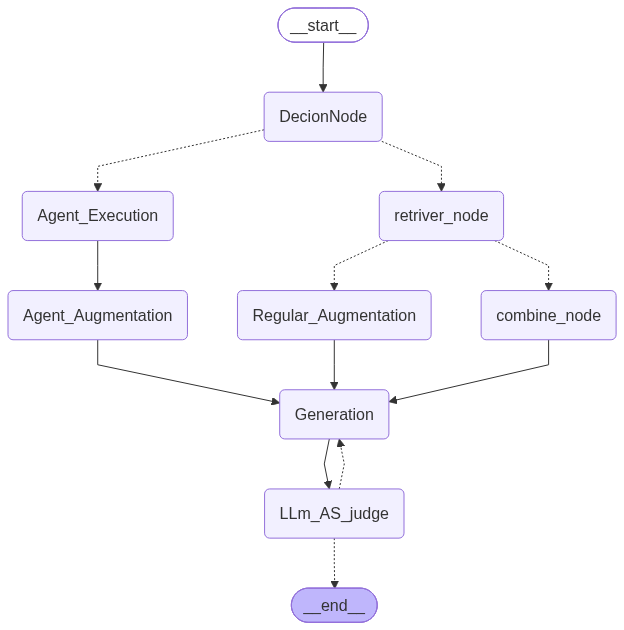

In [76]:
builder = StateGraph(RagSchema)


builder.add_node("DecionNode", DecionNode)
builder.add_node("retriver_node", retriver_node)

builder.add_node("Regular_Augmentation", Regular_Augmentation)
builder.add_node("Agent_Augmentation", Agent_Augmentation)
builder.add_node("Generation", Generation)
builder.add_node("Agent_Execution", Agent_Execution)
builder.add_node("combine_node", combine_node)
builder.add_node("LLm_AS_judge", LLm_AS_judge)



builder.add_edge(START , "DecionNode")
builder.add_conditional_edges("DecionNode",Deciosn_Router_final, {"retriver_node": "retriver_node",
                                                             "Agent_Execution": "Agent_Execution",
                                                               } )

builder.add_conditional_edges('retriver_node',Retrive_router, {"Regular_Augmentation" : "Regular_Augmentation",
                                                               "combine_node": "combine_node"} )


builder.add_edge("Regular_Augmentation", "Generation")
builder.add_edge("Agent_Execution", "Agent_Augmentation")
builder.add_edge("Agent_Augmentation", "Generation")
builder.add_edge("combine_node", "Generation")
builder.add_edge("Generation", "LLm_AS_judge")
builder.add_conditional_edges("LLm_AS_judge", route_judge, {END: END, "Generation": "Generation" } )

app=builder.compile()
app


## ▶️ Test Run #1 — Pure Aggregation Query (expects `Agent` path)

Invokes the compiled `app` with a question requiring **max/sort-based aggregation**: "highest revenue campaign" + "worst 2 campaigns by response rate". No qualitative/descriptive part, so `DecionNode` should classify this as `Agent`, sending it straight through `Agent_Execution → Agent_Augmentation → Generation → LLm_AS_judge`, bypassing vector retrieval entirely. The printed dict is the full final `RagSchema` state after the graph finishes.

In [77]:
user_query = "Which campaign had the highest revenue tell me the revnue as well and also give me the wrost 2 campaigns rr wise?"

result1 = app.invoke({"query": user_query, "max_try":0})
print(result1)

LLM as Judge: The campaign with the highest revenue is CMP1037 with a revenue of 886345.62. The two campaigns with the worst response rates are CMP1033 (1.53%) and CMP1003 (3.60%).
{'query': 'Which campaign had the highest revenue tell me the revnue as well and also give me the wrost 2 campaigns rr wise?', 'augmented_question': ChatPromptValue(messages=[SystemMessage(content='You are a data analyst assistant.\n- You are given a computed answer (from a pandas aggregation) along with the pandas query used.\n- Your job is to present this computed answer clearly and confidently to the user in natural language.\n- The computed answer IS the ground truth — do not second-guess it or say "I don\'t know" if a computed value is present.\n- If Any number is there return the number in a natrual lanugae as per the query given.\n- No assumtion should make without fact support \n- only data driven insight nothing extra', additional_kwargs={}, response_metadata={}), HumanMessage(content="Context :\nTh

## 🔑 Inspect Result State Keys (Query #1)

Lists every field present in `result1` (the `RagSchema` dict returned by the graph) — useful as a quick reference for what's available to inspect after a run. Note `'context'` is absent here since this query took the pure `Agent` path and never touched `retriver_node`.

In [78]:
result1.keys()

dict_keys(['query', 'augmented_question', 'decison', 'agent_ans', 'final_ans', 'pandas_query', 'regular_query', 'verdict', 'judge_decison', 'judge_feedback', 'max_try'])

## 📝 Final Answer, Iteration Count & Judge Feedback (Query #1)

Prints `final_ans` (the generated answer), `max_try` (how many judge/generation rounds it took — `1` means the judge approved on the first pass), and the full `judge_feedback` history for this run.

In [79]:
print(result1['final_ans'])
print()
print(result1['max_try'])
print()
print(result1['judge_feedback'])


- **Highest revenue campaign:** CMP1037 — **886,345.62**
- **Two campaigns with the lowest response rates:**
  1. CMP1033 — **1.53%**
  2. CMP1003 — **3.60%**

1

["The agent answer fully addresses the user's query regarding the campaign with the highest revenue and the two campaigns with the worst response rates. Even though there was no initial context, the answer is grounded in the provided pandas queries and clearly states the campaign IDs and corresponding revenue and response rate percentages. There is coherence between the pandas aggregation and the textual response."]


## 🐼 Raw Pandas Agent Output (Query #1)

Prints `agent_ans` — the **raw, unformatted** output straight from the pandas dataframe agent, before `Agent_Augmentation`/`Generation` rephrased it into the final natural-language answer. Useful for verifying the underlying computation was correct independent of the LLM's phrasing.

In [80]:
print(result1['agent_ans'])

The campaign with the highest revenue is CMP1037 with a revenue of 886345.62. The two campaigns with the worst response rates are CMP1033 (1.53%) and CMP1003 (3.60%).


## ▶️ Test Run #2 — Pure Descriptive Query (expects `Regular` path)

Invokes `app` with a purely qualitative question about two named campaigns ("tell me about... and why the rr is so less") — no explicit aggregation needed since both response rates were already surfaced in the previous run's answer. This should route through `retriver_node → Regular_Augmentation → Generation → LLm_AS_judge`, exercising the full Self-Query + Parent-Child fusion + contextual compression path end-to-end. Only `final_ans` is printed.

In [81]:
user_query = "Tell me abouth the campaign CMP1033 and CMP1003 and why the rr is so less"

result = app.invoke({"query": user_query, "max_try":0})
print(result['final_ans'])


LLM as Judge: Campaign CMP1003, targeting New User customers with a loyalty reward push, had a response rate of 3.6%. The low response rate is due to moderate campaign performance with the segment underperforming vs benchmark, as noted in the insight. The reactivation push was successful but overall lift and engagement were limited.  

Campaign CMP1033, targeting Frequent Buyer customers with a festive season campaign, had an even lower response rate of 1.53%. Despite strong revenue lift overall, low engagement in reactivation efforts contributed to the low response rate as highlighted in the reactivation description.
LLM as Judge: Campaign CMP1003, targeting New User customers with a loyalty reward push, had a response rate of 3.6%. The low response rate is due to moderate campaign performance with the segment underperforming vs benchmark, as noted in the insight. The reactivation push was successful but overall lift and engagement were limited.  

Campaign CMP1033, targeting Frequent

## ▶️ Test Run #3 — Mixed Query (expects `Both` path), with Timing

Invokes `app` with a question that mixes an **aggregation part** ("compare average revenue between North and South", "top territory") and a **descriptive part** ("tell me about CMP1033 and CMP1003 and why the rr is so low") in a single prompt. This should make `DecionNode` return `decison = "Both"`, routing through `retriver_node → combine_node` (which runs the pandas agent *and* merges its output with retrieved context) before `Generation`.

Wall-clock time is measured around the call (`start`/`end`) and printed as `TTFT` — note this actually measures the **full end-to-end latency** of the graph run (including any judge/regeneration loops), not literally "time to first token."

In [82]:
import time 

start=time.time()

user_query = """Compare the average revenue between North and South territories, 
and tell me which one performed better in the territory revenue wise top territory campaign.
and Tell me abouth the campaign CMP1033 and CMP1003 and why the rr is so less
"""



result = app.invoke({"query": user_query})

end=time.time()
print(f"TTFT :{end-start}")




LLM as Judge: - Comparing average revenue, South (≈450,402) performs better than North (≈403,524).  
- The top revenue territory overall is West, with top campaign CMP1038 generating revenue of 808,760.85 and a strong response rate of 19.65%.  
- For campaigns CMP1003 and CMP1033: both show very low response rates (3.6% for CMP1003 and 1.53% for CMP1033). Their low response rates are attributed to minimal lift against control groups and ineffective reactivation efforts, as described in their cross-group and reactivation descriptions. CMP1003’s performance was moderate and below benchmark, while CMP1033 saw low engagement on reactivation campaigns.
LLM as Judge: - Comparing average revenue, South (≈450,402) performs better than North (≈403,524).  
- The top revenue territory overall is West, with top campaign CMP1038 generating revenue of 808,760.85 and a strong response rate of 19.65%.  
- For campaigns CMP1003 and CMP1033: both show very low response rates (3.6% for CMP1003 and 1.53% 

## 🔍 Full State Dump (Query #3)

Prints every relevant field of the `Both`-path result: original query, routing decision, drafted `regular_query`/`pandas_query`, number of judge iterations (`max_try`), the raw pandas agent answer, and the final generated answer — a complete trace for debugging the most complex ("Both") branch of the graph.

In [83]:
print("*************************Query*******************")
print(result['query'])
print("********************************Decion taken***************")
print()
print(result["decison"])
print("*******************Regular Query*****************")
print(result["regular_query"])
print("************************Pandas Query**************")
print(result["pandas_query"])
print("********************max Try**********************")
print(result["max_try"])
print("****************AGET ANS*************************")
print()
print(result["agent_ans"])
print("********************************FIANL ANS***************")
print()
print(result["final_ans"])

*************************Query*******************
Compare the average revenue between North and South territories, 
and tell me which one performed better in the territory revenue wise top territory campaign.
and Tell me abouth the campaign CMP1033 and CMP1003 and why the rr is so less

********************************Decion taken***************

Both
*******************Regular Query*****************
Tell me about the campaign CMP1033 and CMP1003 and why the response rate (rr) is so low.
************************Pandas Query**************
df.groupby('territory')['revenue'].mean()
********************max Try**********************
2
****************AGET ANS*************************

- Comparing average revenue, South (≈450,402) performs better than North (≈403,524).  
- The top revenue territory overall is West, with top campaign CMP1038 generating revenue of 808,760.85 and a strong response rate of 19.65%.  
- For campaigns CMP1003 and CMP1033: both show very low response rates (3.6% for

## ⚖️ Judge Feedback History (Query #3)

Prints the accumulated `judge_feedback` list for query #3. Since `max_try` was `2` for this run, this shows **two rounds** of judging: the first pass flagging specific groundedness issues (e.g., territory-scope mismatch, an unsupported claim about CMP1003), and the second pass approving the corrected answer — a concrete demonstration of the judge → regenerate self-correction loop actually improving the output.

In [84]:
print(result['judge_feedback'])


["The agent answer provides a comparison of average revenue between South and North and identifies West territory with top campaign CMP1038 as the top revenue territory. It also discusses CMP1033 and CMP1003's low response rates with some context. However, the agent answer does not use the context information effectively; the detailed reasons for low response rates are available in the context and should be included explicitly (like minimal lift against control groups and ineffective reactivation efforts). The answer also mistakenly identifies CMP1038 (West) as the top revenue campaign but the query and context focus on North and South; thus, the territory focus is slightly off. Furthermore, the context contains no information on CMP1003, which the agent answer assumes info about, indicating a gap or possible hallucination. Hence, the answer needs improvement to accurately ground on the provided context and maintain consistency with query focus.", "The agent's answer is well grounded i

## 🔑 Inspect Result State Keys (Query #3)

Same as the earlier `result1.keys()` check, but for `result` (query #3). Note `'context'` **is** present this time, since the `Both` path runs `retriver_node` before `combine_node`.

In [85]:
result.keys()

dict_keys(['query', 'context', 'augmented_question', 'decison', 'agent_ans', 'final_ans', 'pandas_query', 'regular_query', 'verdict', 'judge_decison', 'judge_feedback', 'max_try'])

## 🐼 Pandas Query Used (Query #3)

Prints `result['pandas_query']` — the exact pandas expression `DecionNode` drafted for the aggregation half of the mixed query (`df.groupby('territory')['revenue'].mean()`), which `combine_node` then handed to the pandas agent to execute.

In [86]:
result['pandas_query']

"df.groupby('territory')['revenue'].mean()"

## ✅ Final Formatted Answer (Query #3)

Re-prints `result['final_ans']` — the polished, judge-approved answer covering **both** halves of the mixed query: the territory revenue comparison (with the top-performing territory/campaign) and the qualitative explanation of why `CMP1033` and `CMP1003` had low response rates. This is the end-to-end deliverable of the fused retrieval + agentic routing + self-correcting generation pipeline.

In [87]:
print(result['final_ans'])


### North vs. South average revenue

- **South:** approximately **450,402**
- **North:** approximately **403,524**

Therefore, **South performed better than North by about 46,878 in average revenue**.

Among the two territories, South’s stronger results are supported by campaigns such as **CMP1029**, where New User customers responded **15% better than the control group** and the campaign generated strong revenue lift. However, **CMP1007** had only moderate performance and underperformed its benchmark, so its offer structure should be revised.

### Top territory and campaign

Considering all territories, the computed results identify **West as the top revenue territory**, with campaign **CMP1038** generating **808,760.85** in revenue and a **19.65% response rate**.

However, if the comparison is restricted specifically to **North and South**, **South is the better-performing territory on average revenue**. The supplied data does not provide enough campaign-level revenue information to 